In [15]:
import numpy as np
import vicsek_core  # This imports the compiled .so file!
import math as mt
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import warnings
import time
from numba import njit

In [16]:
@njit
def getY(x,theta,boxL):
    cos = np.cos(theta)
    sin = np.sin(theta)
    m = boxL/25
    trig = m*np.column_stack((cos,sin))
    y1 = x[:,0]+trig[:,0]
    y2 = x[:,1]+trig[:,1]
    y = np.column_stack((y1,y2))
    return y

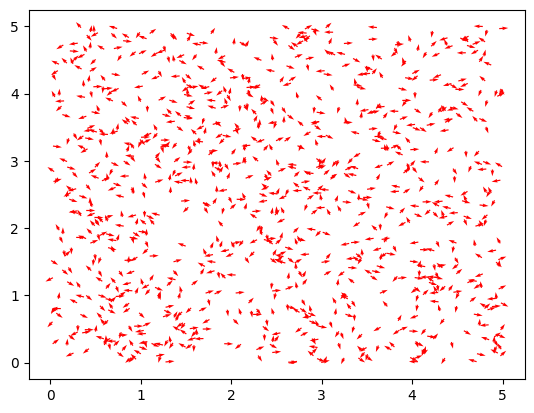

In [17]:
#Parameters
boxL = 5
num_part = 1000
np.random.seed(100)

x = np.random.random((num_part,2))*boxL
theta = np.random.random((num_part,1))*2*np.pi

y =  getY(x,theta,boxL)

#Plotting
dx = y[:,0] - x[:,0]
dy = y[:,1] - x[:,1]
plt.quiver(x[:,0], x[:,1], dx, dy,
           angles='xy',
           scale_units='xy',
           scale=2,
           color='red')

In [18]:
# Parameters
noise = 0.1     # Strength of noise
v = 0.5         # Constant Velocity Term
rad_int = 0.1   # Interaction Radius

# Update
t = 500         # Time of evolution
dt = 0.01
n = int(t / dt)

# Since Fortran directly updates x and theta and we passed intent(in,out), you can do:
x, theta = vicsek_core.evolve(x, theta, n, rad_int, noise, v, dt, boxL)


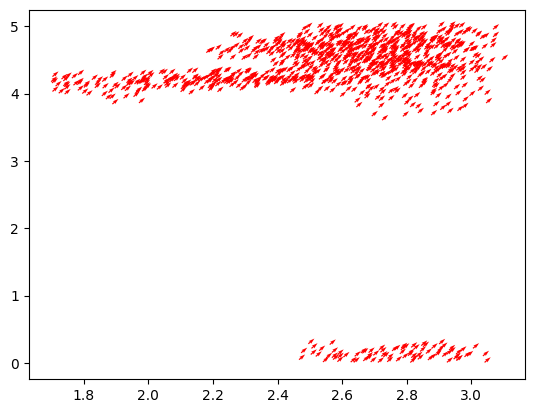

In [19]:
y =  getY(x,theta,boxL)
#Plotting
dx = y[:,0] - x[:,0]
dy = y[:,1] - x[:,1]
plt.quiver(x[:,0], x[:,1], dx, dy,
           angles='xy',
           scale_units='xy',
           scale=2.5,
           color='red')